<a href="https://colab.research.google.com/github/UmaMaheshwari225a3/DataScience_Task/blob/main/Taxi_trip_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#importing the necessary librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
df = pd.read_csv("/content/taxi_trip_pricing (1).csv")

EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [6]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [7]:
df.drop_duplicates(inplace=True)
df.shape

(1000, 11)

In [8]:
# handle null values
mean = df['Trip_Distance_km'].mean()
df['Trip_Distance_km'].fillna(mean, inplace=True)
df

/tmp/ipykernel_233/3186940569.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Trip_Distance_km'].fillna(mean, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [9]:
# handle null values
mode = df['Time_of_Day'].mode()[0]
df['Time_of_Day'].fillna(mode, inplace=True)
df

/tmp/ipykernel_233/627264998.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_of_Day'].fillna(mode, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [10]:
# handle null values
mode = df['Day_of_Week'].mode()[0]
df['Day_of_Week'].fillna(mode, inplace=True)
df

/tmp/ipykernel_233/594613374.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Day_of_Week'].fillna(mode, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [11]:
# handle null values
mode = df['Passenger_Count'].mode()[0]
df['Passenger_Count'].fillna(mode, inplace=True)
df

/tmp/ipykernel_233/1736602201.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Passenger_Count'].fillna(mode, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [12]:
# handle null values
mode = df['Traffic_Conditions'].mode()[0]
df['Traffic_Conditions'].fillna(mode, inplace=True)

/tmp/ipykernel_233/1305492145.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Traffic_Conditions'].fillna(mode, inplace=True)


In [13]:
# handle null values
mode = df['Weather'].mode()[0]
df['Weather'].fillna(mode, inplace=True)
df

/tmp/ipykernel_233/2780189817.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weather'].fillna(mode, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [14]:
# handle null values
mean = df['Base_Fare'].mean()
df['Base_Fare'].fillna(mean, inplace=True)
df

/tmp/ipykernel_233/3721285867.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Base_Fare'].fillna(mean, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.560000,0.80,0.32,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,3.502989,0.62,0.43,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.700000,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.480000,0.51,0.15,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.930000,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.390000,0.62,0.49,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.120000,0.61,NaN,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.080000,1.78,NaN,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.670000,0.82,0.17,114.94,61.2090


In [15]:
# handle null values
mean = df['Per_Km_Rate'].mean()
df['Per_Km_Rate'].fillna(mean, inplace=True)
df

/tmp/ipykernel_233/1052533227.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Per_Km_Rate'].fillna(mean, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.560000,0.800000,0.32,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,3.502989,0.620000,0.43,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.700000,1.210000,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.480000,0.510000,0.15,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.930000,0.630000,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.390000,0.620000,0.49,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.120000,0.610000,NaN,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.080000,1.780000,NaN,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.670000,0.820000,0.17,114.94,61.2090


In [16]:
# handle null values in Per_Minute_Rate column
mean = df['Per_Minute_Rate'].mean()
df['Per_Minute_Rate'].fillna(mean, inplace=True)
df

/tmp/ipykernel_233/1395776118.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Per_Minute_Rate'].fillna(mean, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.560000,0.800000,0.320000,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,3.502989,0.620000,0.430000,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.700000,1.210000,0.150000,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.480000,0.510000,0.150000,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.930000,0.630000,0.320000,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.390000,0.620000,0.490000,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.120000,0.610000,0.292916,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.080000,1.780000,0.292916,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.670000,0.820000,0.170000,114.94,61.2090


In [17]:

# handle null values in Trip_Duration_Minutes column
mean = df['Trip_Duration_Minutes'].mean()
df['Trip_Duration_Minutes'].fillna(mean, inplace=True)
df

/tmp/ipykernel_233/1942539163.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Trip_Duration_Minutes'].fillna(mean, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.560000,0.800000,0.320000,53.82,36.2624
1,47.590000,Afternoon,Weekday,1.0,High,Clear,3.502989,0.620000,0.430000,40.57,NaN
2,36.870000,Evening,Weekend,1.0,High,Clear,2.700000,1.210000,0.150000,37.27,52.9032
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.480000,0.510000,0.150000,116.81,36.4698
4,27.070547,Evening,Weekday,3.0,High,Clear,2.930000,0.630000,0.320000,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.390000,0.620000,0.490000,58.39,34.4049
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.120000,0.610000,0.292916,61.96,62.1295
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.080000,1.780000,0.292916,54.18,33.1236
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.670000,0.820000,0.170000,114.94,61.2090


In [18]:
# handle null values in Trip_Price column
mean = df['Trip_Price'].mean()
df['Trip_Price'].fillna(mean, inplace=True)
df

/tmp/ipykernel_233/2066074161.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Trip_Price'].fillna(mean, inplace=True)


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3.0,Low,Clear,3.560000,0.800000,0.320000,53.82,36.262400
1,47.590000,Afternoon,Weekday,1.0,High,Clear,3.502989,0.620000,0.430000,40.57,56.874773
2,36.870000,Evening,Weekend,1.0,High,Clear,2.700000,1.210000,0.150000,37.27,52.903200
3,30.330000,Evening,Weekday,4.0,Low,Clear,3.480000,0.510000,0.150000,116.81,36.469800
4,27.070547,Evening,Weekday,3.0,High,Clear,2.930000,0.630000,0.320000,22.64,15.618000
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,Afternoon,Weekend,4.0,Medium,Clear,2.390000,0.620000,0.490000,58.39,34.404900
996,45.950000,Night,Weekday,4.0,Medium,Clear,3.120000,0.610000,0.292916,61.96,62.129500
997,7.700000,Morning,Weekday,3.0,Low,Rain,2.080000,1.780000,0.292916,54.18,33.123600
998,47.560000,Morning,Weekday,1.0,Low,Clear,2.670000,0.820000,0.170000,114.94,61.209000


In [19]:
# encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Time_of_Day'] = label_encoder.fit_transform(df['Time_of_Day'])
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,Weekday,3.0,Low,Clear,3.560000,0.800000,0.320000,53.82,36.262400
1,47.590000,0,Weekday,1.0,High,Clear,3.502989,0.620000,0.430000,40.57,56.874773
2,36.870000,1,Weekend,1.0,High,Clear,2.700000,1.210000,0.150000,37.27,52.903200
3,30.330000,1,Weekday,4.0,Low,Clear,3.480000,0.510000,0.150000,116.81,36.469800
4,27.070547,1,Weekday,3.0,High,Clear,2.930000,0.630000,0.320000,22.64,15.618000
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,0,Weekend,4.0,Medium,Clear,2.390000,0.620000,0.490000,58.39,34.404900
996,45.950000,3,Weekday,4.0,Medium,Clear,3.120000,0.610000,0.292916,61.96,62.129500
997,7.700000,2,Weekday,3.0,Low,Rain,2.080000,1.780000,0.292916,54.18,33.123600
998,47.560000,2,Weekday,1.0,Low,Clear,2.670000,0.820000,0.170000,114.94,61.209000


In [20]:
# encoding on Day_of_Week column
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Day_of_Week'] = label_encoder.fit_transform(df['Day_of_Week'])
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,0,3.0,Low,Clear,3.560000,0.800000,0.320000,53.82,36.262400
1,47.590000,0,0,1.0,High,Clear,3.502989,0.620000,0.430000,40.57,56.874773
2,36.870000,1,1,1.0,High,Clear,2.700000,1.210000,0.150000,37.27,52.903200
3,30.330000,1,0,4.0,Low,Clear,3.480000,0.510000,0.150000,116.81,36.469800
4,27.070547,1,0,3.0,High,Clear,2.930000,0.630000,0.320000,22.64,15.618000
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,0,1,4.0,Medium,Clear,2.390000,0.620000,0.490000,58.39,34.404900
996,45.950000,3,0,4.0,Medium,Clear,3.120000,0.610000,0.292916,61.96,62.129500
997,7.700000,2,0,3.0,Low,Rain,2.080000,1.780000,0.292916,54.18,33.123600
998,47.560000,2,0,1.0,Low,Clear,2.670000,0.820000,0.170000,114.94,61.209000


In [21]:
# encoding on Traffic_Conditions column
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Traffic_Conditions'] = label_encoder.fit_transform(df['Traffic_Conditions'])
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,0,3.0,1,Clear,3.560000,0.800000,0.320000,53.82,36.262400
1,47.590000,0,0,1.0,0,Clear,3.502989,0.620000,0.430000,40.57,56.874773
2,36.870000,1,1,1.0,0,Clear,2.700000,1.210000,0.150000,37.27,52.903200
3,30.330000,1,0,4.0,1,Clear,3.480000,0.510000,0.150000,116.81,36.469800
4,27.070547,1,0,3.0,0,Clear,2.930000,0.630000,0.320000,22.64,15.618000
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,0,1,4.0,2,Clear,2.390000,0.620000,0.490000,58.39,34.404900
996,45.950000,3,0,4.0,2,Clear,3.120000,0.610000,0.292916,61.96,62.129500
997,7.700000,2,0,3.0,1,Rain,2.080000,1.780000,0.292916,54.18,33.123600
998,47.560000,2,0,1.0,1,Clear,2.670000,0.820000,0.170000,114.94,61.209000


In [22]:
# encoding on Weather column
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Weather'] = label_encoder.fit_transform(df['Weather'])
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,0,3.0,1,0,3.560000,0.800000,0.320000,53.82,36.262400
1,47.590000,0,0,1.0,0,0,3.502989,0.620000,0.430000,40.57,56.874773
2,36.870000,1,1,1.0,0,0,2.700000,1.210000,0.150000,37.27,52.903200
3,30.330000,1,0,4.0,1,0,3.480000,0.510000,0.150000,116.81,36.469800
4,27.070547,1,0,3.0,0,0,2.930000,0.630000,0.320000,22.64,15.618000
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,0,1,4.0,2,0,2.390000,0.620000,0.490000,58.39,34.404900
996,45.950000,3,0,4.0,2,0,3.120000,0.610000,0.292916,61.96,62.129500
997,7.700000,2,0,3.0,1,1,2.080000,1.780000,0.292916,54.18,33.123600
998,47.560000,2,0,1.0,1,0,2.670000,0.820000,0.170000,114.94,61.209000


<Axes: >

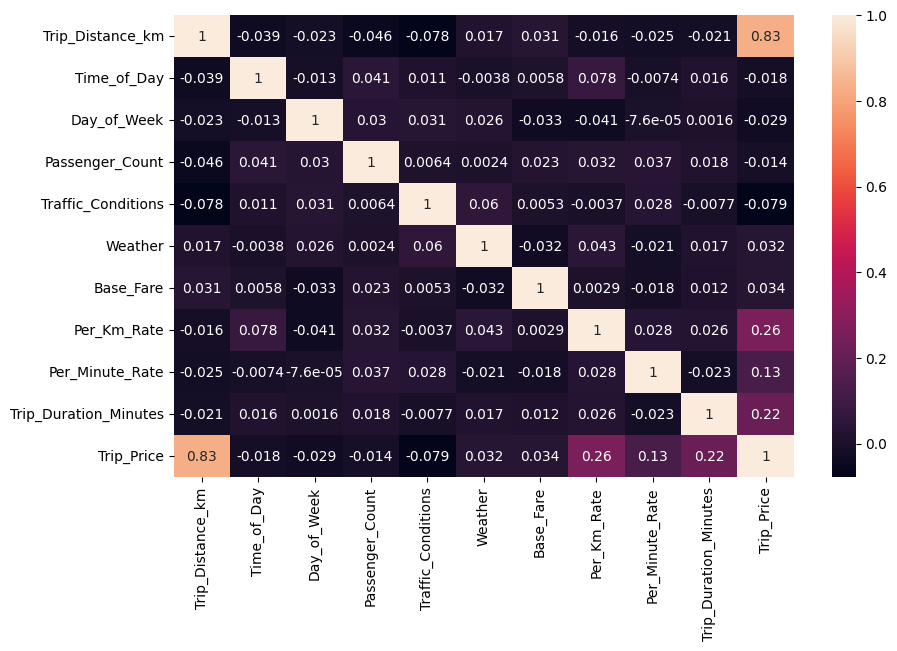

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True)

Model Training

In [24]:
X = df.drop('Trip_Price', axis=1)
y = df['Trip_Price']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3, random_state=42)

Model training

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
print("Intercept: ",model.intercept_)
print("Slope: ",model.coef_)

Intercept:  -56.83023211030949
Slope:  [ 1.72226536 -0.38897265  0.05661157 -0.15707509  0.20144744  1.18913664
  0.96322406 24.77450971 51.27240016  0.28687856]


Model Prediction

In [29]:
ypre = model.predict(X_test)
ypre

array([ 7.57501746e+01,  8.79517142e+01,  6.55756183e+01,  7.30264447e+01,
        1.18179223e+02,  7.22777314e+01,  2.44287080e+01,  5.31044701e+01,
        3.07886461e+01,  7.71454788e+01,  7.42888631e+01,  1.00955283e+02,
        7.41568910e+01,  2.67331790e+01, -4.21867345e-01,  5.22842269e+00,
        6.95721771e+01,  1.79100090e+01,  2.23253100e+01,  3.66593679e+01,
        7.87118938e+01,  3.96061492e+01, -2.47864233e+01,  3.42242721e+01,
        4.34909869e+01,  9.15866749e+01,  6.96933470e+01,  4.36340507e+01,
        3.51133135e+01,  9.27920904e+01,  8.35969608e+01,  8.62630862e+01,
        1.39495142e+01,  1.04912047e+02,  3.97160754e+01,  9.54710054e+01,
        2.31238410e+01,  5.85189338e+01,  2.57924313e+01,  7.65366430e+01,
        5.16852410e+01,  3.69245499e+01,  7.65076640e-01,  3.28760870e+01,
        1.40738307e+01,  6.05148699e+01,  5.33210799e+01,  4.52112942e+01,
        4.29763504e+01,  4.84404989e+01,  6.35332207e+01,  8.93449163e+00,
        8.40887634e+01,  

In [30]:
print("Training Score: ",model.score(X_train, y_train))
print("Testing Score: ",model.score(X_test, y_test))

Training Score:  0.8538877857090447
Testing Score:  0.7771019667797486


In [32]:
# evaluation matrix
print("Metrics: ")
r2 = r2_score(y_test,ypre)
print("R2: ",r2)
print("MSE: ",mean_squared_error(y_test,ypre))
print("MAE: ",mean_absolute_error(y_test,ypre))

Metrics: 
R2:  0.7771019667797486
MSE:  290.12763457229215
MAE:  10.396689625543852


In [33]:
new_data = df.iloc[:1,:-1]
pred = model.predict(new_data)[0]
print("Predicted Price : $",pred*100000)

Predicted Price : $ 3054353.701371469
